# 2.3 rewrite - Agent 버전

기존 `StateGraph` 구조를 `create_agent()` 기반 Agent 구조로 변경한 노트북입니다.

기존 구조:

```text
START → retrieve → check_doc_relevance → generate 또는 rewrite → retrieve 반복
```

변경 구조:

```text
사용자 질문 → Agent → 필요 시 search_pension_law tool 호출 → 최종 답변
```

핵심 차이는 검색 로직을 LangGraph 노드가 아니라 **Agent가 사용할 수 있는 tool**로 등록했다는 점입니다.


In [3]:
%pip install langchain_chroma langchain_upstage

     --------------------------------------- 23.5/23.5 MB 34.4 MB/s eta 0:00:00
     ------------------------------------- 349.5/349.5 kB 21.2 MB/s eta 0:00:00
     ---------------------------------------- 2.4/2.4 MB 76.5 MB/s eta 0:00:00
     --------------------------------------- 13.4/13.4 MB 59.4 MB/s eta 0:00:00
     ------------------------------------- 178.9/178.9 kB 10.5 MB/s eta 0:00:00
     ---------------------------------------- 60.6/60.6 kB 3.4 MB/s eta 0:00:00
     ---------------------------------------- 4.9/4.9 MB 16.6 MB/s eta 0:00:00
     -------------------------------------- 150.9/150.9 kB 8.8 MB/s eta 0:00:00
     ---------------------------------------- 4.6/4.6 MB 59.1 MB/s eta 0:00:00
     ---------------------------------------- 41.5/41.5 kB 2.0 MB/s eta 0:00:00
     ------------------------------------- 566.4/566.4 kB 34.8 MB/s eta 0:00:00
     ---------------------------------------- 42.8/42.8 kB ? eta 0:00:00
     ---------------------------------------- 203.


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from dotenv import load_dotenv

load_dotenv()


True

## 1. Chroma Vector Store / Retriever 준비


In [4]:
from langchain_chroma import Chroma
from langchain_upstage import UpstageEmbeddings

embedding_function = UpstageEmbeddings(model="solar-embedding-1-large")

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name="pension_law_collection",
    persist_directory="./pension_law_collection",
)

retriever = vector_store.as_retriever(search_kwargs={"k": 3})


## 2. 사전 정의

기존 `rewrite` 노드에서 사용하던 용어 사전을 Agent의 시스템 프롬프트에 넣습니다.  
Agent는 사용자 질문에 일상어가 포함되어 있으면 법령/업무 용어로 해석해서 검색 tool을 사용합니다.


In [8]:
dictionary = [
    "직장인 -> 사업장가입자",
    "회사원 -> 사업장가입자",
    "근로자 -> 사업장가입자",
    "개인사업자 -> 지역가입자",
    "자영업자 -> 지역가입자",
    "프리랜서 -> 지역가입자",
    "학생 -> 임의가입자",
    "전업주부 -> 임의가입자",
    "주부 -> 임의가입자",
    "외국인 -> 외국인가입자",
    "연금 보험료 -> 연금보험료",
    "국민연금 보험료 -> 연금보험료",
    "보험료 미납 -> 연금보험료 체납",
    "연금 못 냄 -> 연금보험료 체납",
    "가입 해지 -> 가입자 자격 상실",
    "탈퇴 -> 가입자 자격 상실",
    "가입 시작일 -> 자격 취득 시기",
    "가입 끝나는 날 -> 자격 상실 시기",
    "수급자 -> 수급권자",
    "연금 받는 사람 -> 수급권자",
    "노후연금 -> 노령연금",
    "장애 보상 -> 장애연금",
    "사망 후 연금 -> 유족연금",
    "배우자 연금 -> 유족연금",
]

# 시스템 프롬프트에 넣기 좋게 문자열로 변환합니다.
dictionary_text = """.join(f"- {item}" for item in dictionary)"""


## 3. Retriever를 Tool로 변경

기존에는 `retrieve(state)` 노드가 문서를 검색했습니다.  
Agent 버전에서는 검색 함수를 `@tool`로 감싸서 Agent가 직접 호출할 수 있게 합니다.


In [10]:
from langchain_core.tools import tool


def docs_to_text(docs) -> str:
    """검색된 Document 리스트를 Agent tool의 반환값으로 쓰기 좋은 문자열로 변환합니다."""
    if not docs:
        return "관련 문서를 찾지 못했습니다."

    chunks = []

    for idx, doc in enumerate(docs, start=1):
        content = getattr(doc, "page_content", "") or ""
        metadata = getattr(doc, "metadata", {}) or {}

        source = (
            metadata.get("source")
            or metadata.get("file_path")
            or metadata.get("title")
            or metadata.get("filename")
            or "출처 정보 없음"
        )
        page = metadata.get("page") or metadata.get("page_number")

        header = f"[검색 결과 {idx}]\n출처: {source}"
        if page is not None:
            header += f"\n페이지: {page}"

        chunks.append(f"{header}\n내용:\n{content}")

    return "\n\n---\n\n".join(chunks)


@tool
def search_pension_law(query: str) -> str:
    """국민연금 관련 법령/문서에서 질문과 관련된 내용을 검색합니다."""
    docs = retriever.invoke(query)
    return docs_to_text(docs)

## 4. ChatUpstage 모델과 Agent 생성

`create_agent()`에 모델과 tool을 넘깁니다.  
이제 Agent가 질문을 보고 필요하면 `search_pension_law` tool을 호출한 뒤 답변합니다.


In [11]:
from langchain_upstage import ChatUpstage
from langchain.agents import create_agent

llm = ChatUpstage()

generate_system_prompt = f"""
You are an assistant for question-answering tasks about 국민연금 and related pension law documents.

You have access to a search tool named `search_pension_law`.
Use this tool when you need information from the pension law document collection.

사용자의 질문에 아래 사전의 일상 표현이 들어 있으면, 대응되는 법령/업무 용어로 해석해서 검색하세요.

사전:
{dictionary_text}

답변 규칙:
1. 검색 결과에 근거해서 답변하세요.
2. 검색 결과에서 답을 찾을 수 없으면 모른다고 답하세요.
3. 가능하면 3문장 이내로 간결하게 답변하세요.
4. 사용자가 한국어로 질문하면 한국어로 답변하세요.
"""

agent = create_agent(
    model=llm,
    tools=[search_pension_law],
    system_prompt=generate_system_prompt,
)


## 5. 실행

기존 `graph.invoke(initial_state)` 대신 `agent.invoke()`를 사용합니다.


In [12]:
query = "일반적으로 직장인은 언제 연금을 수령할수 있나요?"

result = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": query}
        ]
    }
)

result


{'messages': [HumanMessage(content='일반적으로 직장인은 언제 연금을 수령할수 있나요?', additional_kwargs={}, response_metadata={}, id='501eb20d-f0a0-4ccb-9d3c-584465d7fc15'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 434, 'total_tokens': 526, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'solar-mini-250422', 'system_fingerprint': None, 'id': 'da7b0f6d-3e85-411e-b298-ba4fcd1dcca6', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019efdb8-b65b-7f11-8147-03539a638bc2-0', tool_calls=[{'name': 'search_pension_law', 'args': {'query': '직장인 연금 수령 시기'}, 'id': '0d85f324-fa94-4493-95a1-be8c75b06b38', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 434, 'output_tokens': 92, 'total_t

## 6. 최종 답변만 출력

`create_agent()`의 결과에는 전체 메시지 히스토리가 들어 있습니다.  
마지막 메시지가 최종 답변입니다.


In [13]:
final_answer = result["messages"][-1].content
print(final_answer)


직장인이 일반적으로 연금을 수령할 수 있는 시기는 국민연금법에 따라 정해져 있습니다. 그러나 구체적인 수령 시기는 개인의 가입 기간, 소득 수준, 연령 등에 따라 달라질 수 있습니다. 따라서 정확한 수령 시기는 국민연금공단에 문의하여 확인하시는 것이 좋습니다.


## 7. 선택 사항: AgentMiddleware 추가 예시

아래 셀은 선택 사항입니다.  
모델 호출 전후 로그를 보고 싶거나, 질문/응답을 검사하고 싶을 때 사용할 수 있습니다.

> 단, 설치된 LangChain 버전에 따라 `AgentMiddleware` import 경로나 hook 시그니처가 달라질 수 있습니다.


In [14]:
# 선택 사항: 미들웨어를 사용하고 싶을 때만 실행하세요.

from langchain.agents.middleware import AgentMiddleware


class LoggingMiddleware(AgentMiddleware):
    def before_model(self, state, runtime):
        print("[Middleware] 모델 호출 직전")
        return None

    def after_model(self, state, runtime):
        print("[Middleware] 모델 호출 직후")
        return None


agent_with_middleware = create_agent(
    model=llm,
    tools=[search_pension_law],
    system_prompt=generate_system_prompt,
    middleware=[LoggingMiddleware()],
)


In [15]:
# 미들웨어 적용 Agent 실행 예시

middleware_result = agent_with_middleware.invoke(
    {
        "messages": [
            {"role": "user", "content": query}
        ]
    }
)

print(middleware_result["messages"][-1].content)


[Middleware] 모델 호출 직전
[Middleware] 모델 호출 직후
직장인이 일반적으로 연금을 수령할 수 있는 시기는 국민연금법에 따라 60세부터입니다. 그러나, 개인적인 상황에 따라 연금 수령 시기는 달라질 수 있습니다.


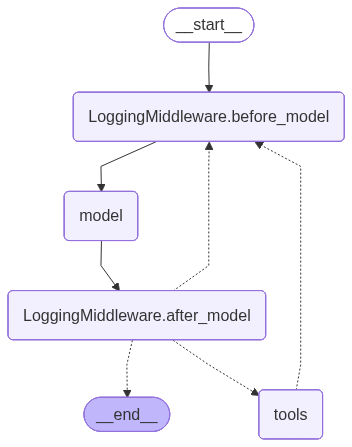

In [18]:
from IPython.display import Image, display

display(Image(agent_with_middleware.get_graph().draw_mermaid_png()))